# AI Business Report Generator

## Project 6 — AI Automation Portfolio

This project uses Python, Data Analysis, Prompt Engineering, Google Colab, and the OpenAI API to transform structured business data into professional reports, performance insights, business risks, and actionable recommendations.


## Project Goal

The goal of this project is to automate business reporting by combining Python-based metric calculations with AI-generated analysis. The application converts business performance data into a clear, accurate, decision-focused report that helps identify strengths, challenges, trends, risks, and recommended actions.


## Step 2.1: Business Data Preparation and Report Prompt Design

In this section, sample monthly business data is created and analyzed with Python. Key performance metrics are calculated and inserted into a structured AI prompt for generating a professional, evidence-based business report.


In [ ]:
import pandas as pd

### Creating the Sample Business Dataset

In [ ]:
# Sample monthly business data

business_data = {
    "Month": [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June"
    ],

    "Revenue": [
        120000,
        128000,
        135000,
        142000,
        150000,
        162000
    ],

    "Expenses": [
        82000,
        85000,
        88000,
        93000,
        98000,
        104000
    ],

    "New_Customers": [
        420,
        455,
        490,
        530,
        575,
        620
    ],

    "Marketing_Spend": [
        12000,
        13000,
        14500,
        15000,
        16500,
        18000
    ]
}

# Create a pandas DataFrame

df = pd.DataFrame(business_data)

# Display the dataset

df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend
0,January,120000,82000,420,12000
1,February,128000,85000,455,13000
2,March,135000,88000,490,14500
3,April,142000,93000,530,15000
4,May,150000,98000,575,16500
5,June,162000,104000,620,18000


### Calculate Monthly Profit

In [ ]:
# Calculate monthly profit

df["Profit"] = (
    df["Revenue"] - df["Expenses"]
)

# Display the updated dataset

df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend,Profit
0,January,120000,82000,420,12000,38000
1,February,128000,85000,455,13000,43000
2,March,135000,88000,490,14500,47000
3,April,142000,93000,530,15000,49000
4,May,150000,98000,575,16500,52000
5,June,162000,104000,620,18000,58000


### Calculate Profit Margin

In [ ]:
# Calculate profit margin percentage

df["Profit_Margin_Percentage"] = (
    df["Profit"] / df["Revenue"] * 100
).round(2)

df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend,Profit,Profit_Margin_Percentage
0,January,120000,82000,420,12000,38000,31.67
1,February,128000,85000,455,13000,43000,33.59
2,March,135000,88000,490,14500,47000,34.81
3,April,142000,93000,530,15000,49000,34.51
4,May,150000,98000,575,16500,52000,34.67
5,June,162000,104000,620,18000,58000,35.80


### Calculating Revenue Growth

In [ ]:
# Calculate month-to-month revenue growth

df["Revenue_Growth_Percentage"] = (
    df["Revenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend,Profit,Profit_Margin_Percentage,Revenue_Growth_Percentage
0,January,120000,82000,420,12000,38000,31.67,NaN
1,February,128000,85000,455,13000,43000,33.59,6.67
2,March,135000,88000,490,14500,47000,34.81,5.47
3,April,142000,93000,530,15000,49000,34.51,5.19
4,May,150000,98000,575,16500,52000,34.67,5.63
5,June,162000,104000,620,18000,58000,35.80,8.00


### Calculating Key Business Totals

In [ ]:
# Calculate key business totals

total_revenue = df["Revenue"].sum()

total_expenses = df["Expenses"].sum()

total_profit = df["Profit"].sum()

total_new_customers = (
    df["New_Customers"].sum()
)

total_marketing_spend = (
    df["Marketing_Spend"].sum()
)

overall_profit_margin = (
    total_profit / total_revenue * 100
)

print(
    "Total Revenue:",
    f"${total_revenue:,.0f}"
)

print(
    "Total Expenses:",
    f"${total_expenses:,.0f}"
)

print(
    "Total Profit:",
    f"${total_profit:,.0f}"
)

print(
    "Total New Customers:",
    f"{total_new_customers:,}"
)

print(
    "Total Marketing Spend:",
    f"${total_marketing_spend:,.0f}"
)

print(
    "Overall Profit Margin:",
    f"{overall_profit_margin:.2f}%"
)

Total Revenue: $837,000
Total Expenses: $550,000
Total Profit: $287,000
Total New Customers: 3,090
Total Marketing Spend: $89,000
Overall Profit Margin: 34.29%


### Calculate Customer Acquisition Cost

We will calculate a simple marketing-based customer acquisition cost:

Customer Acquisition Cost =
Total Marketing Spend ÷ Total New Customers

In [ ]:
# Calculate customer acquisition cost

customer_acquisition_cost = (
    total_marketing_spend
    / total_new_customers
)

print(
    "Customer Acquisition Cost:",
    f"${customer_acquisition_cost:.2f}"
)

Customer Acquisition Cost: $28.80


### Identify the Strongest and Weakest Months

In [ ]:
# Identify key performance months

highest_revenue_month = (
    df.loc[
        df["Revenue"].idxmax(),
        "Month"
    ]
)

highest_profit_month = (
    df.loc[
        df["Profit"].idxmax(),
        "Month"
    ]
)

lowest_profit_month = (
    df.loc[
        df["Profit"].idxmin(),
        "Month"
    ]
)

highest_growth_month = (
    df.loc[
        df["Revenue_Growth_Percentage"].idxmax(),
        "Month"
    ]
)

print(
    "Highest Revenue Month:",
    highest_revenue_month
)

print(
    "Highest Profit Month:",
    highest_profit_month
)

print(
    "Lowest Profit Month:",
    lowest_profit_month
)

print(
    "Highest Revenue Growth Month:",
    highest_growth_month
)

Highest Revenue Month: June
Highest Profit Month: June
Lowest Profit Month: January
Highest Revenue Growth Month: June


### Creating a Business Data Summary

In [ ]:
# Create a structured business summary

business_summary = f"""
REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
${total_revenue:,.0f}

Total Expenses:
${total_expenses:,.0f}

Total Profit:
${total_profit:,.0f}

Overall Profit Margin:
{overall_profit_margin:.2f}%

Total New Customers:
{total_new_customers:,}

Total Marketing Spend:
${total_marketing_spend:,.0f}

Customer Acquisition Cost:
${customer_acquisition_cost:.2f}

PERFORMANCE HIGHLIGHTS

Highest Revenue Month:
{highest_revenue_month}

Highest Profit Month:
{highest_profit_month}

Lowest Profit Month:
{lowest_profit_month}

Highest Revenue Growth Month:
{highest_growth_month}

MONTHLY BUSINESS DATA

{df.to_string(index=False)}
"""

print(business_summary)


REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
$837,000

Total Expenses:
$550,000

Total Profit:
$287,000

Overall Profit Margin:
34.29%

Total New Customers:
3,090

Total Marketing Spend:
$89,000

Customer Acquisition Cost:
$28.80

PERFORMANCE HIGHLIGHTS

Highest Revenue Month:
June

Highest Profit Month:
June

Lowest Profit Month:
January

Highest Revenue Growth Month:
June

MONTHLY BUSINESS DATA

   Month  Revenue  Expenses  New_Customers  Marketing_Spend  Profit  Profit_Margin_Percentage  Revenue_Growth_Percentage
 January   120000     82000            420            12000   38000                     31.67                        NaN
February   128000     85000            455            13000   43000                     33.59                       6.67
   March   135000     88000            490            14500   47000                     34.81                       5.47
   April   142000     93000            530            15000   49000                    

### Designing the AI Business-Report Prompt

In [ ]:
# Create the structured AI business-report prompt

prompt = f"""
You are an expert business analyst, financial-performance
analyst, data analyst, and business-report writer.

Your task is to transform the business data below into a clear,
professional, evidence-based, and decision-focused business report.

BUSINESS DATA

{business_summary}

REPORTING REQUIREMENTS

Use only the information provided.

Do not invent:

- Business facts
- Financial figures
- Causes of performance changes
- Market conditions
- Customer behavior
- Competitor information
- Business outcomes
- Future results

If a cause cannot be confirmed from the data, describe it as
a possibility or recommend further investigation.

Clearly distinguish:

- Facts calculated from the data
- Data-supported observations
- Business recommendations
- Areas requiring additional information

ANALYSIS REQUIREMENTS

1. Analyze revenue performance.
2. Analyze expense performance.
3. Analyze profit and profit-margin performance.
4. Analyze customer-growth performance.
5. Analyze marketing-spend trends.
6. Interpret customer acquisition cost carefully.
7. Identify important month-to-month trends.
8. Identify strengths supported by the data.
9. Identify risks or areas requiring attention.
10. Do not treat correlation as proof of causation.
11. Do not make unsupported predictions.
12. Keep the report concise, clear, and professional.
13. Use business-friendly language.
14. Use headings and bullet points where useful.

Use exactly this report structure:

# Business Performance Report

## Reporting Period

## Executive Summary

Provide a concise overview of the business performance.

## Key Performance Metrics

Summarize:

- Total revenue
- Total expenses
- Total profit
- Overall profit margin
- Total new customers
- Total marketing spend
- Customer acquisition cost

## Revenue Performance

Analyze revenue trends and important changes.

## Expense and Profit Performance

Analyze expenses, profit, and profit margin.

## Customer Growth and Marketing Performance

Analyze new-customer growth, marketing spending,
and customer acquisition cost.

## Key Performance Highlights

Identify the strongest results supported by the data.

## Business Strengths

List data-supported strengths.

## Risks and Areas for Attention

Identify risks, concerns, or areas requiring further review.

## Recommended Actions

Provide 3 to 5 practical recommendations.

For each recommendation, include:

- Priority: High, Medium, or Low
- Recommended action
- Reason based on the data

## Data Limitations

Explain what additional information would improve the analysis.

## Conclusion

Provide a concise decision-focused conclusion.
"""

### Displying the Complete Prompt

In [ ]:
print(prompt)


You are an expert business analyst, financial-performance
analyst, data analyst, and business-report writer.

Your task is to transform the business data below into a clear,
professional, evidence-based, and decision-focused business report.

BUSINESS DATA


REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
$837,000

Total Expenses:
$550,000

Total Profit:
$287,000

Overall Profit Margin:
34.29%

Total New Customers:
3,090

Total Marketing Spend:
$89,000

Customer Acquisition Cost:
$28.80

PERFORMANCE HIGHLIGHTS

Highest Revenue Month:
June

Highest Profit Month:
June

Lowest Profit Month:
January

Highest Revenue Growth Month:
June

MONTHLY BUSINESS DATA

   Month  Revenue  Expenses  New_Customers  Marketing_Spend  Profit  Profit_Margin_Percentage  Revenue_Growth_Percentage
 January   120000     82000            420            12000   38000                     31.67                        NaN
February   128000     85000            455            13000   43000   

## Step 2.2: AI-Powered Business Report Generation

In this section, the structured business-report prompt is connected to the OpenAI API. The AI analyzes the Python-calculated business metrics and generates a professional, evidence-based, decision-focused business report.


### Installing the OpenAI Python Library

In [ ]:
!pip install -q openai

### Load the API Key Securely

Using the business OPENAI_API_KEY secret may need to be saved securely in Google Colab.

In [ ]:
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")

if api_key:
    print("OpenAI API key loaded successfully.")
else:
    print("OpenAI API key was not found.")

### Creating the OpenAI Client

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

print("OpenAI client created successfully.")

### Generating the AI Business Report

In [ ]:
# Generate the AI-powered business report

response = client.responses.create(
    model="gpt-5-mini",
    input=prompt
)

business_report = response.output_text

print(business_report)

## Review the Report

The generated report confirms that it includes the correct values such as:
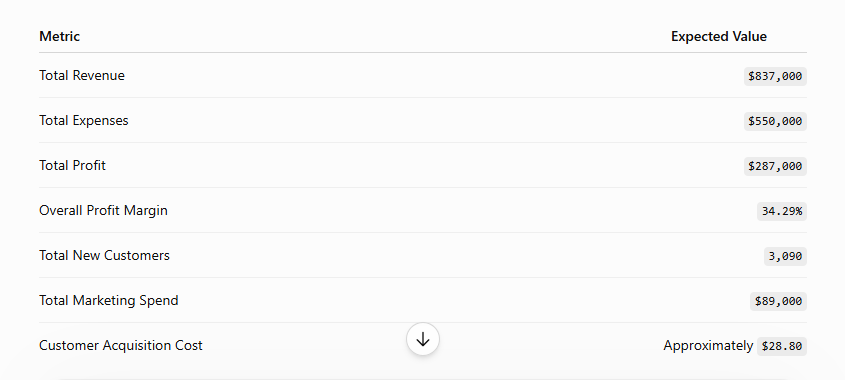

#3 Also we confirms the following:
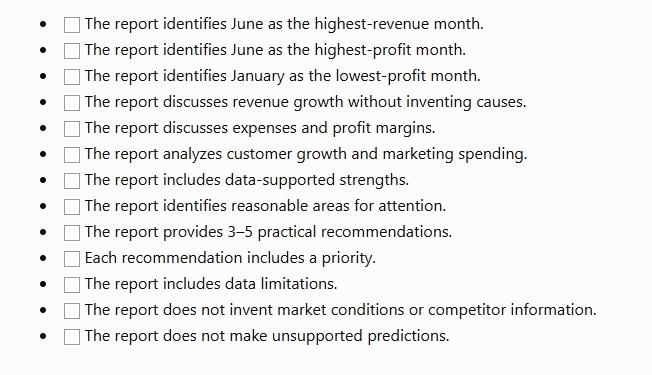

### So Our Initial AI Business Report

The first AI-generated report was created using Python-calculated business metrics and a structured, evidence-based prompt. The report summarizes business performance, identifies important trends, highlights strengths and areas for attention, and provides prioritized recommendations.

AI-generated results may vary. The report should be reviewed before being used for important financial, operational, or strategic decisions.


## Step 3.1: Scenario Testing and Business-Report Prompt Refinement

This section tests the AI Business Report Generator using a second business scenario with mixed performance. The prompt is refined to improve numerical accuracy, trend analysis, evidence-based reporting, risk identification, and recommendation quality.


### Create the Second Business Scenario

In [ ]:
# Second business scenario:
# Growth followed by performance pressure

scenario_2_data = {
    "Month": [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June"
    ],

    "Revenue": [
        150000,
        158000,
        165000,
        160000,
        154000,
        148000
    ],

    "Expenses": [
        98000,
        104000,
        112000,
        116000,
        119000,
        122000
    ],

    "New_Customers": [
        620,
        650,
        680,
        610,
        560,
        510
    ],

    "Marketing_Spend": [
        18000,
        19500,
        21000,
        22500,
        24000,
        26000
    ]
}

scenario_2_df = pd.DataFrame(
    scenario_2_data
)

scenario_2_df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend
0,January,150000,98000,620,18000
1,February,158000,104000,650,19500
2,March,165000,112000,680,21000
3,April,160000,116000,610,22500
4,May,154000,119000,560,24000
5,June,148000,122000,510,26000


## Calculating Scenario 2 Metrics

In [ ]:
# Calculate profit

scenario_2_df["Profit"] = (
    scenario_2_df["Revenue"]
    - scenario_2_df["Expenses"]
)

# Calculate profit margin

scenario_2_df[
    "Profit_Margin_Percentage"
] = (
    scenario_2_df["Profit"]
    / scenario_2_df["Revenue"]
    * 100
).round(2)

# Calculate month-to-month revenue growth

scenario_2_df[
    "Revenue_Growth_Percentage"
] = (
    scenario_2_df["Revenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

scenario_2_df

,Month,Revenue,Expenses,New_Customers,Marketing_Spend,Profit,Profit_Margin_Percentage,Revenue_Growth_Percentage
0,January,150000,98000,620,18000,52000,34.67,NaN
1,February,158000,104000,650,19500,54000,34.18,5.33
2,March,165000,112000,680,21000,53000,32.12,4.43
3,April,160000,116000,610,22500,44000,27.50,-3.03
4,May,154000,119000,560,24000,35000,22.73,-3.75
5,June,148000,122000,510,26000,26000,17.57,-3.90


## Calculate Scenario 2 Totals

In [ ]:
# Calculate scenario totals

scenario_2_total_revenue = (
    scenario_2_df["Revenue"].sum()
)

scenario_2_total_expenses = (
    scenario_2_df["Expenses"].sum()
)

scenario_2_total_profit = (
    scenario_2_df["Profit"].sum()
)

scenario_2_total_customers = (
    scenario_2_df["New_Customers"].sum()
)

scenario_2_total_marketing = (
    scenario_2_df["Marketing_Spend"].sum()
)

scenario_2_profit_margin = (
    scenario_2_total_profit
    / scenario_2_total_revenue
    * 100
)

scenario_2_cac = (
    scenario_2_total_marketing
    / scenario_2_total_customers
)

print(
    "Total Revenue:",
    f"${scenario_2_total_revenue:,.0f}"
)

print(
    "Total Expenses:",
    f"${scenario_2_total_expenses:,.0f}"
)

print(
    "Total Profit:",
    f"${scenario_2_total_profit:,.0f}"
)

print(
    "Overall Profit Margin:",
    f"{scenario_2_profit_margin:.2f}%"
)

print(
    "Total New Customers:",
    f"{scenario_2_total_customers:,}"
)

print(
    "Total Marketing Spend:",
    f"${scenario_2_total_marketing:,.0f}"
)

print(
    "Customer Acquisition Cost:",
    f"${scenario_2_cac:.2f}"
)

Total Revenue: $935,000
Total Expenses: $671,000
Total Profit: $264,000
Overall Profit Margin: 28.24%
Total New Customers: 3,630
Total Marketing Spend: $131,000
Customer Acquisition Cost: $36.09


### Calculate Important Performance Changes

In [ ]:
# Calculate important changes

revenue_change = (
    (
        scenario_2_df.loc[5, "Revenue"]
        - scenario_2_df.loc[0, "Revenue"]
    )
    / scenario_2_df.loc[0, "Revenue"]
    * 100
)

expense_change = (
    (
        scenario_2_df.loc[5, "Expenses"]
        - scenario_2_df.loc[0, "Expenses"]
    )
    / scenario_2_df.loc[0, "Expenses"]
    * 100
)

profit_change = (
    (
        scenario_2_df.loc[5, "Profit"]
        - scenario_2_df.loc[0, "Profit"]
    )
    / scenario_2_df.loc[0, "Profit"]
    * 100
)

customer_change = (
    (
        scenario_2_df.loc[5, "New_Customers"]
        - scenario_2_df.loc[0, "New_Customers"]
    )
    / scenario_2_df.loc[0, "New_Customers"]
    * 100
)

marketing_change = (
    (
        scenario_2_df.loc[5, "Marketing_Spend"]
        - scenario_2_df.loc[0, "Marketing_Spend"]
    )
    / scenario_2_df.loc[0, "Marketing_Spend"]
    * 100
)

print(
    "January-to-June Revenue Change:",
    f"{revenue_change:.2f}%"
)

print(
    "January-to-June Expense Change:",
    f"{expense_change:.2f}%"
)

print(
    "January-to-June Profit Change:",
    f"{profit_change:.2f}%"
)

print(
    "January-to-June Customer Change:",
    f"{customer_change:.2f}%"
)

print(
    "January-to-June Marketing Change:",
    f"{marketing_change:.2f}%"
)

January-to-June Revenue Change: -1.33%
January-to-June Expense Change: 24.49%
January-to-June Profit Change: -50.00%
January-to-June Customer Change: -17.74%
January-to-June Marketing Change: 44.44%


### Create the Scenario 2 Business Summary

In [ ]:
scenario_2_summary = f"""
REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
${scenario_2_total_revenue:,.0f}

Total Expenses:
${scenario_2_total_expenses:,.0f}

Total Profit:
${scenario_2_total_profit:,.0f}

Overall Profit Margin:
{scenario_2_profit_margin:.2f}%

Total New Customers:
{scenario_2_total_customers:,}

Total Marketing Spend:
${scenario_2_total_marketing:,.0f}

Customer Acquisition Cost:
${scenario_2_cac:.2f}

JANUARY-TO-JUNE CHANGES

Revenue Change:
{revenue_change:.2f}%

Expense Change:
{expense_change:.2f}%

Profit Change:
{profit_change:.2f}%

New-Customer Change:
{customer_change:.2f}%

Marketing-Spend Change:
{marketing_change:.2f}%

MONTHLY BUSINESS DATA

{scenario_2_df.to_string(index=False)}
"""

print(scenario_2_summary)


REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
$935,000

Total Expenses:
$671,000

Total Profit:
$264,000

Overall Profit Margin:
28.24%

Total New Customers:
3,630

Total Marketing Spend:
$131,000

Customer Acquisition Cost:
$36.09

JANUARY-TO-JUNE CHANGES

Revenue Change:
-1.33%

Expense Change:
24.49%

Profit Change:
-50.00%

New-Customer Change:
-17.74%

Marketing-Spend Change:
44.44%

MONTHLY BUSINESS DATA

   Month  Revenue  Expenses  New_Customers  Marketing_Spend  Profit  Profit_Margin_Percentage  Revenue_Growth_Percentage
 January   150000     98000            620            18000   52000                     34.67                        NaN
February   158000    104000            650            19500   54000                     34.18                       5.33
   March   165000    112000            680            21000   53000                     32.12                       4.43
   April   160000    116000            610            22500   44000       

## Creating the Refined Business-Report Prompt

In [ ]:
refined_prompt = f"""
You are an expert business analyst, financial-performance
analyst, data analyst, and executive-report writer.

Create a professional, evidence-based, decision-focused
business performance report using only the data provided.

BUSINESS DATA

{scenario_2_summary}

DATA ACCURACY RULES

1. Use only the provided data and calculated metrics.
2. Do not invent business facts, financial figures,
   market conditions, customer behavior, competitor activity,
   operational causes, or future outcomes.
3. Do not assume that correlation proves causation.
4. Do not claim that marketing spending caused changes in
   customer acquisition unless supporting evidence is provided.
5. If the cause of a trend is unknown, state that the data
   does not establish the cause.
6. Clearly distinguish facts, observations, risks,
   recommendations, and information gaps.
7. Do not change or recalculate the provided metrics.
8. Use exact values where important.
9. Use percentage changes carefully.
10. Do not describe a small change as a major change
    without explaining the context.
11. Do not make unsupported forecasts.
12. Do not describe a risk as a confirmed business failure.

TREND-ANALYSIS RULES

1. Compare the beginning and end of the reporting period.
2. Identify changes in revenue, expenses, profit,
   profit margin, customer acquisition, and marketing spend.
3. Identify whether trends improved, weakened,
   remained stable, or changed direction.
4. Highlight important changes in profitability.
5. Discuss the relationship between marketing spending
   and customer acquisition as an observation only.
6. Identify areas requiring investigation rather than
   assigning unsupported causes.
7. Explain why a trend may require management attention.

RECOMMENDATION RULES

Each recommendation must:

- Be practical.
- Be connected to a data-supported observation.
- Avoid unsupported assumptions.
- Include a priority level.
- Explain the business reason.
- Include a measurable follow-up metric when possible.

Use exactly this report structure:

# Business Performance Report

## Reporting Period

## Executive Summary

Provide a concise overview of overall performance.

## Key Performance Metrics

Include:

- Total revenue
- Total expenses
- Total profit
- Overall profit margin
- Total new customers
- Total marketing spend
- Customer acquisition cost

## Revenue Trend Analysis

Analyze the monthly revenue pattern.

## Expense and Profit Analysis

Analyze expense growth, profit changes,
and profit-margin performance.

## Customer Growth and Marketing Analysis

Analyze customer acquisition, marketing spending,
and customer acquisition cost.

## Key Performance Highlights

List important data-supported results.

## Key Risks and Areas for Attention

Identify important risks or performance concerns.

For each item, include:

- Observation
- Why it matters
- Information needed for further investigation

## Recommended Actions

Provide 3 to 5 recommendations.

For each recommendation, include:

- Priority: High, Medium, or Low
- Action
- Data-supported reason
- Suggested follow-up metric

## Data Limitations

Explain which additional information would improve
the analysis.

## Conclusion

Provide a concise management-focused conclusion.
"""

print(refined_prompt)


You are an expert business analyst, financial-performance
analyst, data analyst, and executive-report writer.

Create a professional, evidence-based, decision-focused
business performance report using only the data provided.

BUSINESS DATA


REPORTING PERIOD

January to June

KEY BUSINESS METRICS

Total Revenue:
$935,000

Total Expenses:
$671,000

Total Profit:
$264,000

Overall Profit Margin:
28.24%

Total New Customers:
3,630

Total Marketing Spend:
$131,000

Customer Acquisition Cost:
$36.09

JANUARY-TO-JUNE CHANGES

Revenue Change:
-1.33%

Expense Change:
24.49%

Profit Change:
-50.00%

New-Customer Change:
-17.74%

Marketing-Spend Change:
44.44%

MONTHLY BUSINESS DATA

   Month  Revenue  Expenses  New_Customers  Marketing_Spend  Profit  Profit_Margin_Percentage  Revenue_Growth_Percentage
 January   150000     98000            620            18000   52000                     34.67                        NaN
February   158000    104000            650            19500   54000       

### Generate the Refined Report

In [ ]:
# Generate the refined AI business report

refined_response = client.responses.create(
    model="gpt-5-mini",
    input=refined_prompt
)

refined_business_report = (
    refined_response.output_text
)

print(refined_business_report)

### Evaluate the Refined Report

Let's check that the report correctly identifies:
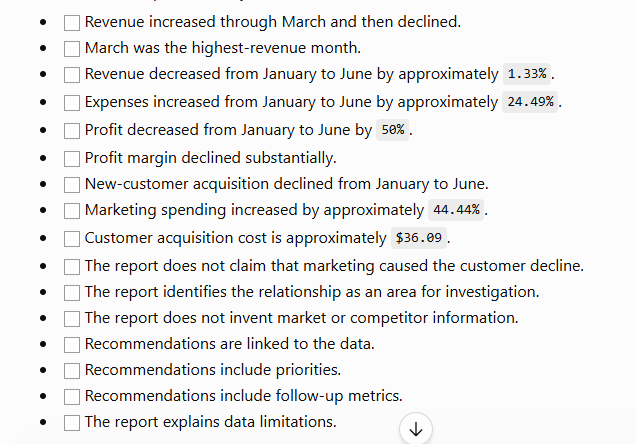

### Scenario 2 Testing Results

The AI Business Report Generator was tested using a mixed-performance business scenario. The scenario included declining revenue after an initial growth period, increasing expenses, falling profit margins, reduced new-customer acquisition, and increased marketing spending.

The prompt was refined to improve numerical accuracy, distinguish observations from causes, prevent unsupported conclusions, strengthen risk analysis, and connect recommendations to measurable follow-up metrics.


## Build an Interactive AI Business Report Generator

## Step 3.2: Interactive AI Business Report Generator

This section allows users to enter business performance data directly into Google Colab. Python calculates the key metrics, and the OpenAI API generates a structured, evidence-based, decision-focused business report.


## Collect Interactive Business Inputs

In [ ]:
# Collect business information from the user

business_name = input(
    "Enter the business name:\n"
)

reporting_period = input(
    "\nEnter the reporting period:\n"
)

total_revenue_input = float(
    input(
        "\nEnter total revenue:\n"
    )
)

total_expenses_input = float(
    input(
        "\nEnter total expenses:\n"
    )
)

total_new_customers_input = int(
    input(
        "\nEnter the total number of new customers:\n"
    )
)

total_marketing_spend_input = float(
    input(
        "\nEnter total marketing spend:\n"
    )
)

print(
    "\nBusiness information received successfully."
)

### By providing the following input data:
Business name:
NovaFit

Reporting period:
July to December 2026

Total revenue:
950000

Total expenses:
670000

Total new customers:
4100

Total marketing spend:
145000

### Calculate the Interactive Business Metrics

In [ ]:
# Calculate key business metrics

interactive_profit = (
    total_revenue_input
    - total_expenses_input
)

interactive_profit_margin = (
    interactive_profit
    / total_revenue_input
    * 100
)

interactive_customer_acquisition_cost = (
    total_marketing_spend_input
    / total_new_customers_input
)

print(
    "Business:",
    business_name
)

print(
    "Reporting Period:",
    reporting_period
)

print(
    "Total Revenue:",
    f"${total_revenue_input:,.2f}"
)

print(
    "Total Expenses:",
    f"${total_expenses_input:,.2f}"
)

print(
    "Total Profit:",
    f"${interactive_profit:,.2f}"
)

print(
    "Profit Margin:",
    f"{interactive_profit_margin:.2f}%"
)

print(
    "New Customers:",
    f"{total_new_customers_input:,}"
)

print(
    "Marketing Spend:",
    f"${total_marketing_spend_input:,.2f}"
)

print(
    "Customer Acquisition Cost:",
    f"${interactive_customer_acquisition_cost:.2f}"
)

The approximate resul output:

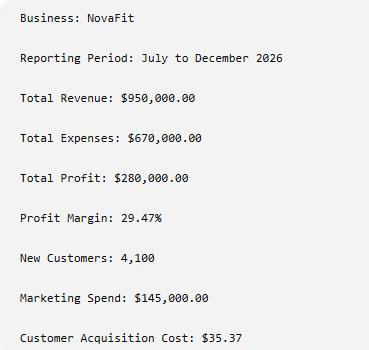

### Add Input Validation

In [ ]:
# Validate the business inputs

if total_revenue_input <= 0:
    print(
        "Error: Total revenue must be greater than zero."
    )

elif total_new_customers_input <= 0:
    print(
        "Error: The number of new customers "
        "must be greater than zero."
    )

elif total_expenses_input < 0:
    print(
        "Error: Total expenses cannot be negative."
    )

elif total_marketing_spend_input < 0:
    print(
        "Error: Marketing spend cannot be negative."
    )

else:
    print(
        "Business inputs are valid."
    )

### Create the Interactive Business Summary

In [ ]:
# Create a structured summary

interactive_business_summary = f"""
BUSINESS NAME

{business_name}

REPORTING PERIOD

{reporting_period}

KEY BUSINESS METRICS

Total Revenue:
${total_revenue_input:,.2f}

Total Expenses:
${total_expenses_input:,.2f}

Total Profit:
${interactive_profit:,.2f}

Profit Margin:
{interactive_profit_margin:.2f}%

Total New Customers:
{total_new_customers_input:,}

Total Marketing Spend:
${total_marketing_spend_input:,.2f}

Customer Acquisition Cost:
${interactive_customer_acquisition_cost:.2f}
"""

print(
    interactive_business_summary
)

### Create the Interactive AI Report Prompt

In [ ]:
# Create the interactive business-report prompt

interactive_report_prompt = f"""
You are an expert business analyst,
financial-performance analyst,
data analyst, and executive-report writer.

Create a professional, concise,
evidence-based, and decision-focused
business report using only the data below.

BUSINESS DATA

{interactive_business_summary}

DATA ACCURACY RULES

1. Use only the provided data and
   calculated metrics.

2. Do not invent:

- Financial figures
- Revenue trends
- Expense trends
- Market conditions
- Customer behavior
- Competitor activity
- Operational causes
- Business outcomes
- Future results

3. Do not claim that one metric caused
   another unless evidence is provided.

4. If the cause of a result is unknown,
   state that the data does not establish
   the cause.

5. Clearly separate:

- Data facts
- Data-supported observations
- Business recommendations
- Information gaps

6. Do not make unsupported forecasts.

7. Do not describe a risk as a confirmed
   business failure.

REPORT REQUIREMENTS

Use exactly this structure:

# Business Performance Report

## Business Name

## Reporting Period

## Executive Summary

## Key Performance Metrics

Include:

- Total revenue
- Total expenses
- Total profit
- Profit margin
- Total new customers
- Total marketing spend
- Customer acquisition cost

## Business Performance Analysis

Interpret the available metrics carefully.

Do not claim trends because only
summary-period data is provided.

## Business Strengths

List strengths supported by the data.

## Risks and Areas for Attention

Identify areas requiring review.

For each area, explain:

- The data observation
- Why it may matter
- What additional information is needed

## Recommended Actions

Provide 3 to 5 actions.

For each action, include:

- Priority:
  High, Medium, or Low

- Recommended action

- Data-supported reason

- Suggested follow-up metric

## Data Limitations

Explain what additional information
would improve the analysis.

## Conclusion

Provide a concise,
management-focused conclusion.
"""

### Generate the Interactive AI Business Report.

In [ ]:
# Generate the interactive AI business report

interactive_response = (
    client.responses.create(
        model="gpt-5-mini",
        input=interactive_report_prompt
    )
)

interactive_business_report = (
    interactive_response.output_text
)

print(
    interactive_business_report
)

## Test a Second Interactive Scenario

```text
Business name:
UrbanCart

Reporting period:
Quarter 1, 2026

Total revenue:
420000

Total expenses:
355000

Total new customers:
1200

Total marketing spend:
72000
```
Expected calculations:
```text
Total Profit:
$65,000.00

Profit Margin:
15.48%

Customer Acquisition Cost:
$60.00
```

## Add an Interactive Testing Note

### Interactive Business Report Testing

The interactive AI Business Report Generator was tested using multiple business scenarios. Users entered a business name, reporting period, revenue, expenses, new-customer count, and marketing spend.

Python calculated profit, profit margin, and customer acquisition cost before the data was sent to the OpenAI API. The AI generated structured business reports containing evidence-based observations, risks, recommended actions, follow-up metrics, and data limitations.

The interactive workflow was designed to avoid unsupported trend claims when only summary-period data was available.


## Final Quality Check

Confirm:
```text

 The user can enter business information directly.
 Financial inputs are converted to float.
 Customer count is converted to int.
 Profit is calculated correctly.
 Profit margin is calculated correctly.
 Customer acquisition cost is calculated correctly.
 Invalid zero or negative values are detected.
 The business summary displays correctly.
 The AI report is generated successfully.
 The report includes the required sections.
 The report does not invent trends.
 The report does not invent causes.
 The report provides prioritized recommendations.
 Recommendations include follow-up metrics.
 The report explains data limitations.
 The second interactive scenario was tested.
 ```

### So, on we will create a reusable report-generation function, run final testing, save sample outputs. In progress...